# Customer Churn Prediction Platform
## Notebook 1 of 4: Data Wrangling

**Author:** L.Beeler  
**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) via Kaggle

### Overview

The IBM Telco Customer Churn dataset covers 7,043 customers of a fictional telecommunications company. Each row represents one customer and includes 21 columns: demographic information (gender, senior citizen status, whether they have a partner or dependents), account details (how long they have been a customer, what type of contract they are on, how much they pay per month), the services they are subscribed to (phone, internet, streaming, online security, tech support, device protection, and online backup), their billing preferences (payment method, paperless billing), and whether they churned. The entire wrangling effort here is focused on understanding the data, catching quality issues, and getting it into a clean shape for feature engineering.

Churn here is an explicit event, a customer either cancelled their service during the observed period or they did not. This makes it fundamentally different from marketplace churn, where you have to infer churn from a gap in purchase activity. The churn rate in this dataset sits around 26%, which is a workable class balance for a binary classification problem.

### Why this dataset

This project originally used the Olist Brazilian e-commerce dataset, which covers 100,000+ orders across a marketplace platform. After building the full wrangling and feature engineering pipeline, a fundamental problem emerged: Olist customers almost never make a second purchase. Around 97% of customers placed exactly one order. When the churn label was defined using a proper time-based split to avoid target leakage, the resulting churn rate was over 98%, which left the model with almost no signal to learn from. The Telco dataset solves both of those problems. Churn here is an explicit event (a customer cancelled their service), not something inferred from a gap in activity, and the churn rate sits around 26%, which is a workable class balance for modeling.

### Project Notebooks
- **01_data_wrangling.ipynb** -- you are here
- 02_feature_engineering.ipynb
- 03_modeling.ipynb
- 04_shap_explainability.ipynb

### What this notebook produces
A clean customer table saved to `data/telco_clean.csv`, ready for feature engineering.

## 1. Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

# Dynamically find the project root
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)

# Define path using os.path.join for cross-platform compatibility
DATA_DIR = os.path.join(project_root, 'data')
data_path = os.path.join(DATA_DIR, 'WA_Fn-UseC_-Telco-Customer-Churn.csv')
OUTPUT_PATH = os.path.join(DATA_DIR, 'telco_clean.csv')

print('Libraries loaded.')
print(f'Data directory: {os.path.abspath(DATA_DIR)}')

Libraries loaded.
Data directory: /Users/Loseph/Desktop/customer-churn-prediction-platform/data


## 2. Load the Raw Data

Loading the single CSV and checking shape before doing anything. This is to confirm everything downloaded correctly and nothing is obviously truncated or empty.

In [19]:
# Verify the file is found before trying to load it
if os.path.exists(data_path):
    df = pd.read_csv(data_path)
    print(f"Success! Loaded dataset with shape: {df.shape}")
else:
    print(f"Error: File not found at {data_path}")

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print()
print(df.head())

Success! Loaded dataset with shape: (7043, 21)
Shape: 7,043 rows x 21 columns

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport Stream

## 3. Explore the Data

Taking a closer look at what is in the dataset before doing anything to it to understand the column types, spot anything that looks off, and discover anything that needs handling.

In [20]:
print('Column types:')
print(df.dtypes)
print()
print('Note: TotalCharges is object (string) instead of float.')
print('This is because 11 customers have blank TotalCharges entries.')
print('This gets fixed in section 5.')

Column types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Note: TotalCharges is object (string) instead of float.
This is because 11 customers have blank TotalCharges entries.
This gets fixed in section 5.


In [21]:
# look at the target variable distribution first
# this tells us how balanced the churn classes are before any modeling decisions are made
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

print('Churn distribution:')
for label in ['No', 'Yes']:
    print(f'  {label}: {churn_counts[label]:,} ({churn_pct[label]:.1f}%)')

Churn distribution:
  No: 5,174 (73.5%)
  Yes: 1,869 (26.5%)


In [22]:
# look at the numerical columns
print('Numerical column summary:')
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

Numerical column summary:
       tenure  MonthlyCharges
count 7043.00         7043.00
mean    32.37           64.76
std     24.56           30.09
min      0.00           18.25
25%      9.00           35.50
50%     29.00           70.35
75%     55.00           89.85
max     72.00          118.75


In [23]:
# look at the categorical columns and their unique values
# this gives a sense of cardinality and whether any columns need special handling
categorical_cols = df.select_dtypes(include='str').columns.tolist()
categorical_cols = [c for c in categorical_cols if c != 'customerID']

print('Categorical columns and unique values:')
for col in categorical_cols:
    vals = df[col].unique()
    print(f'  {col}: {vals}')

Categorical columns and unique values:
  gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str
  Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
  Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  PhoneService: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  MultipleLines: <ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
  InternetService: <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
  OnlineSecurity: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  OnlineBackup: <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
  DeviceProtection: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  TechSupport: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  StreamingTV: <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
  StreamingMovies: <ArrowStrin

## 4. Check for Missing Values

Checking nulls before touching anything. It is much easier to catch and decide how to handle missing data now than to find unexpected NaN values partway through feature engineering.

In [24]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print('No missing values found in any column.')
    print()
    print('Note: TotalCharges has 11 blank string entries that will show up')
    print('as missing after conversion to numeric in the next section.')
else:
    print('Missing values:')
    for col, count in missing.items():
        print(f'  {col}: {count:,} ({count/len(df)*100:.1f}%)')

No missing values found in any column.

Note: TotalCharges has 11 blank string entries that will show up
as missing after conversion to numeric in the next section.


## 5. Data Quality Checks and Fixes

Running a few checks on the raw data to catch issues that could corrupt the analysis later on. For this dataset the main issues are the `TotalCharges` type problem and a small number of customers with no tenure who cannot be meaningfully scored.

In [25]:
# check for duplicate customer IDs
# each row should represent exactly one unique customer
duplicate_ids = df['customerID'].duplicated().sum()
print(f'Duplicate customerID rows: {duplicate_ids}')

Duplicate customerID rows: 0


In [26]:
# fix TotalCharges: convert from string to numeric
# blank strings become NaN, which we can then inspect + handle
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

blank_total_charges = df['TotalCharges'].isnull().sum()
print(f'Rows with blank TotalCharges after conversion: {blank_total_charges}')
print()

# all of these rows have tenure = 0
# meaning they signed up but never completed a billing cycle
# dropping them since there is no meaningful history to learn from
if blank_total_charges > 0:
    print('Customers with blank TotalCharges:')
    print(df[df['TotalCharges'].isnull()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']])
    print()
    df = df.dropna(subset=['TotalCharges'])
    print(f'Dropped {blank_total_charges} rows. Remaining: {len(df):,}')

Rows with blank TotalCharges after conversion: 11

Customers with blank TotalCharges:
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No

Dropped 11 rows. Remaining: 7,032


In [27]:
# confirm the fix worked
print('TotalCharges after conversion:')
print(df['TotalCharges'].describe())
print()
print(f'Missing values remaining: {df["TotalCharges"].isnull().sum()}')

TotalCharges after conversion:
count   7032.00
mean    2283.30
std     2266.77
min       18.80
25%      401.45
50%     1397.47
75%     3794.74
max     8684.80
Name: TotalCharges, dtype: float64

Missing values remaining: 0


In [28]:
# Check: TotalCharges should approximately equal tenure × MonthlyCharges
# a large discrepancy would suggest a data quality issue 
df['expected_total'] = df['tenure'] * df['MonthlyCharges']
df['charge_discrepancy'] = (df['TotalCharges'] - df['expected_total']).abs()

print('TotalCharges vs tenure × MonthlyCharges discrepancy:')
print(df['charge_discrepancy'].describe())
print()
print('Customers with discrepancy > $50:')
print((df['charge_discrepancy'] > 50).sum())

# drop the helper columns, they were just for the check
df = df.drop(columns=['expected_total', 'charge_discrepancy'])

TotalCharges vs tenure × MonthlyCharges discrepancy:
count   7032.00
mean      45.09
std       49.90
min        0.00
25%        9.44
50%       28.65
75%       63.70
max      373.25
Name: charge_discrepancy, dtype: float64

Customers with discrepancy > $50:
2322


The mean discrepancy of \$45 and the 2,322 customers with a gap over \$50 makes sense. Monthly charges change over time as customers add or drop services, so TotalCharges is the actual running total, not just tenure multiplied by the current rate. This means the three features are less redundant than they first appeared. TotalCharges captures lifetime billing history in a way that neither tenure nor current monthly charges alone can replicate, so keeping all three in the model is justified.

In [29]:
# convert the churn label to binary integer
# Yes = 1 (churned), No = 0 (retained)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print('Churn label after conversion:')
print(df['Churn'].value_counts())

Churn label after conversion:
Churn
0    5163
1    1869
Name: count, dtype: int64


## 6. Exploratory Visualizations

A few plots to understand the shape of the data before feature engineering. The goal is to spot distributions that might need special treatment and get a feel for which features could be predictive.

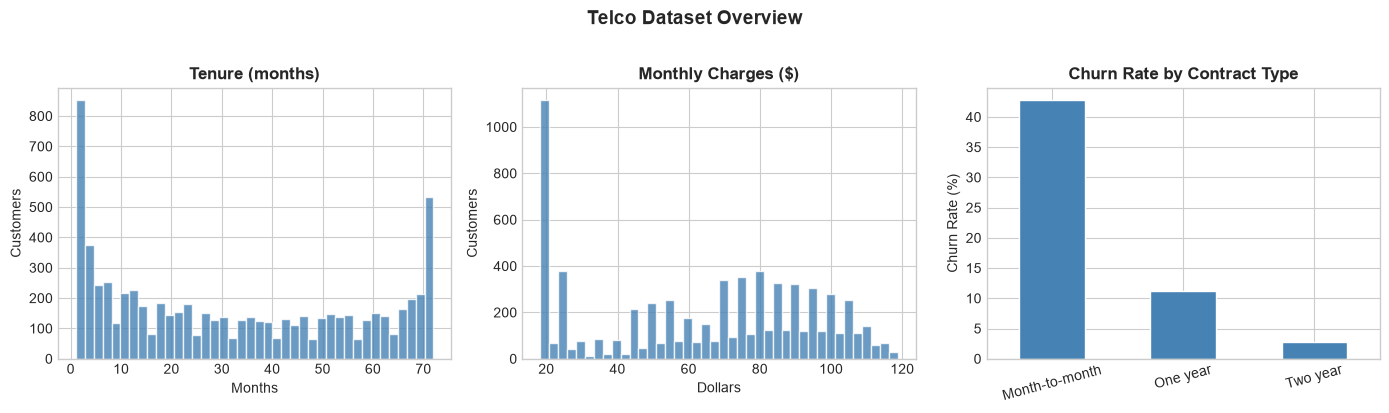

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# tenure distribution
df['tenure'].hist(bins=40, ax=axes[0], color='steelblue', edgecolor='white', alpha=0.8)
axes[0].set_title('Tenure (months)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Months')
axes[0].set_ylabel('Customers')

# monthly charges
df['MonthlyCharges'].hist(bins=40, ax=axes[1], color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Monthly Charges ($)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dollars')
axes[1].set_ylabel('Customers')

# churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
contract_churn.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='white')
axes[2].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].tick_params(axis='x', rotation=15)

plt.suptitle('Telco Dataset Overview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

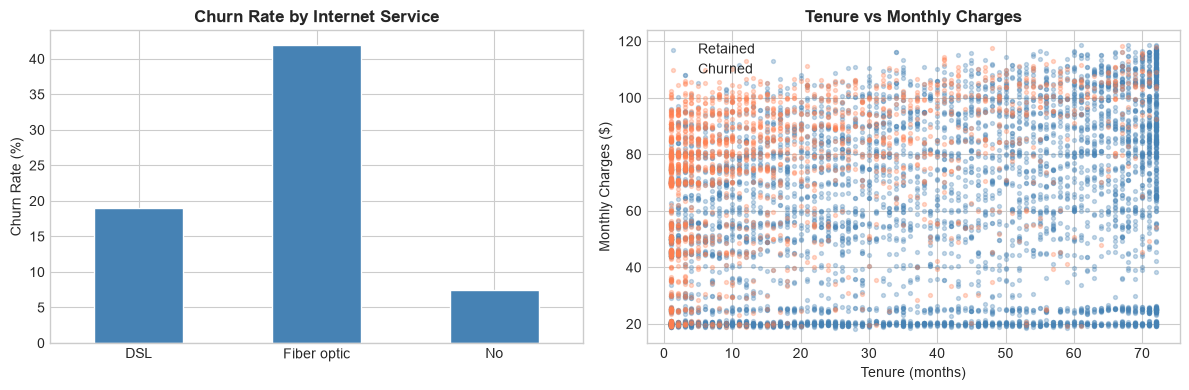

In [31]:
# churn rate by internet service type
# fiber optic customers churn at a much higher rate than DSL or no-internet customers
# which is worth understanding before feature engineering
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

internet_churn = df.groupby('InternetService')['Churn'].mean() * 100
internet_churn.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Churn Rate by Internet Service', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].tick_params(axis='x', rotation=0)

# tenure vs monthly charges, colored by churn
churned    = df[df['Churn'] == 1]
not_churned = df[df['Churn'] == 0]

axes[1].scatter(not_churned['tenure'], not_churned['MonthlyCharges'],
                alpha=0.3, s=8, color='steelblue', label='Retained')
axes[1].scatter(churned['tenure'], churned['MonthlyCharges'],
                alpha=0.3, s=8, color='coral', label='Churned')
axes[1].set_title('Tenure vs Monthly Charges', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Final Checks

In [32]:
print('Clean dataset summary')
print(f'Shape: {df.shape}')
print()
print(f'Churn rate: {df["Churn"].mean()*100:.1f}%')
print()
print('Remaining missing values:')
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]
if remaining_missing.empty:
    print('  None')
else:
    print(remaining_missing)

Clean dataset summary
Shape: (7032, 21)

Churn rate: 26.6%

Remaining missing values:
  None


## 8. Save

Saving the clean customer table so the feature engineering notebook can load it directly.

In [33]:
df.to_csv(OUTPUT_PATH, index=False)

print(f'Saved to: {OUTPUT_PATH}')
print(f'Final shape: {df.shape}')
print()
print('Next: 02_feature_engineering.ipynb')

Saved to: /Users/Loseph/Desktop/customer-churn-prediction-platform/data/telco_clean.csv
Final shape: (7032, 21)

Next: 02_feature_engineering.ipynb


## Summary

| Step | Result |
|------|--------|
| Loaded raw CSV | 7,043 rows x 21 columns |
| Checked data quality | No duplicate IDs, no structural issues |
| Fixed TotalCharges type | Converted from string to numeric, identified 11 blank rows |
| Dropped 11 zero-tenure customers | Customers who signed up but never completed a billing cycle |
| Converted Churn to binary | Yes = 1, No = 0 |
| Explored key distributions | Tenure, monthly charges, churn by contract and internet type |
| Saved telco_clean.csv | Clean table ready for feature engineering |

**Next notebook:** `02_feature_engineering.ipynb` -- encode categorical features, explore feature relationships with churn, and produce the feature matrix for the model.